In [2]:
%run "./Hamiltonian_solver.ipynb"

Best B: 4.1935340839189905
Transition frequency at B: 623.6441051016996
Error: 1.699504537100438e-09
[[         nan 458.98370144 461.92436004 464.86287142 467.79924027]
 [468.14934504 471.09215558 474.03281418 476.97132556 479.90769441]
 [480.60995082 483.55276136 486.49341996 489.43193134          nan]
 [         nan          nan 533.13126916 536.06978054 539.00614939]
 [         nan 536.90749676 539.84815536 542.78666674 545.72303559]
 [540.54867336 543.4914839  546.4321425  549.37065388 552.30702273]
 [546.94119669 549.88400724 552.82466584 555.76317721          nan]
 [553.04626773 555.98907828 558.92973688          nan          nan]
 [         nan          nan          nan 594.80710083 597.74346969]
 [         nan          nan 595.85182764 598.79033901 601.72670787]
 [         nan 597.25713907 600.19779767 603.13630905 606.0726779 ]
 [598.90607348 601.84888402 604.78954262 607.728054   610.66442285]
 [603.71987407 606.66268461 609.60334321 612.54185459          nan]
 [608.79568111 

In [3]:
import numpy as np
import matplotlib.pyplot as plt


S12_STATE_LABELS = [
    r"$|1,-1\rangle$",
    r"$|1,0\rangle$",
    r"$|1,+1\rangle$",
    r"$|2,+2\rangle$",
    r"$|2,+1\rangle$",
    r"$|2,0\rangle$",
    r"$|2,-1\rangle$",
    r"$|2,-2\rangle$",
]

# $S_{1/2}$ Calculations

In [4]:
B_gauss = 4.2079
wavelength_nm = 532

k = 45
phi = 0
chi = 45

beam1_polarization = elliptical_polarization_from_geometry(
    beam_angle_deg=k,
    polarization_angle_deg=phi+180,
    ellipticity_angle_deg=chi-90,
)

beam2_polarization = elliptical_polarization_from_geometry(
    beam_angle_deg=k+90,
    polarization_angle_deg=phi+50,
    ellipticity_angle_deg=chi-45,
)

raman = RamanTransitionStrength_S12(
    B_gauss=B_gauss,
    pol1=beam1_polarization,
    pol2=beam2_polarization,
    wavelength_nm=wavelength_nm,
)

# This is the raw, unnormalized transition-strength matrix.
strength = np.asarray(
    raman["strength"],
    dtype=float,
)

# Remove same-state transitions from the displayed matrix.
# np.fill_diagonal(strength, 0.0)

# strength = strength / np.max(strength) 

print("Maximum off-diagonal strength:", np.max(strength))
print("Matrix shape:", strength.shape)

Maximum off-diagonal strength: 2.8333784012837966e-27
Matrix shape: (8, 8)


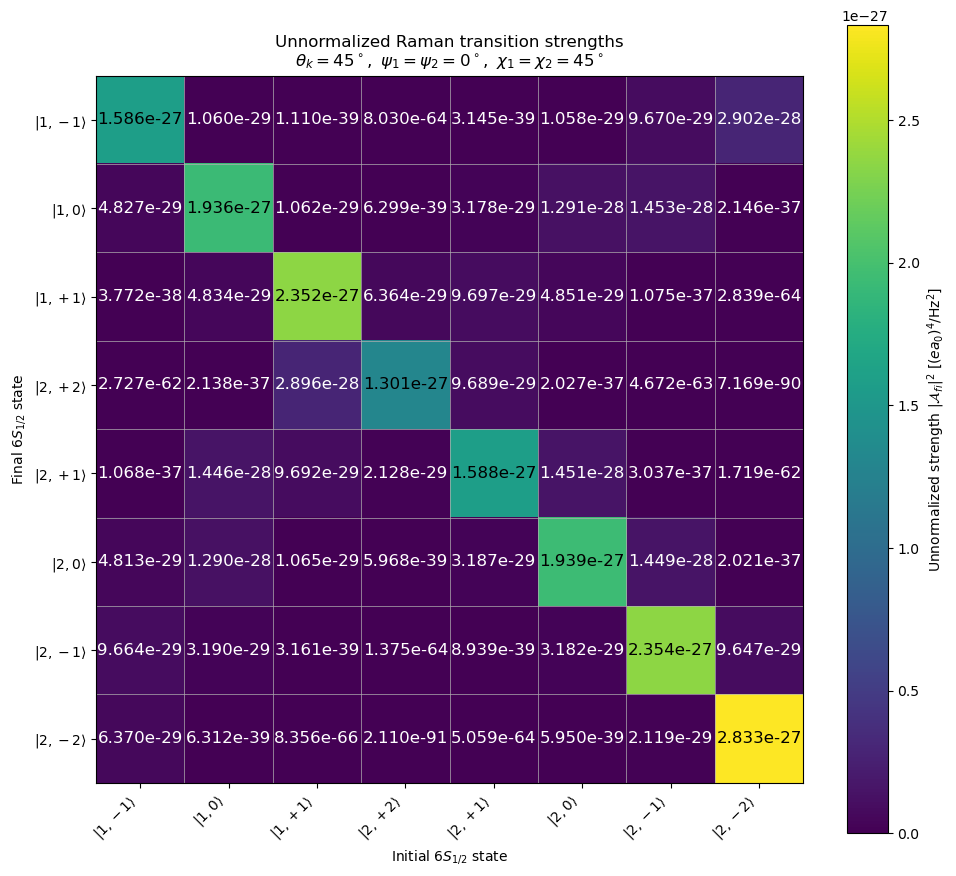

In [5]:
fig, ax = plt.subplots(figsize=(10, 9))

image = ax.imshow(
    strength,
    origin="upper",
    interpolation="nearest",
    aspect="equal",
)

ax.set_xticks(np.arange(len(S12_STATE_LABELS)))
ax.set_yticks(np.arange(len(S12_STATE_LABELS)))

ax.set_xticklabels(
    S12_STATE_LABELS,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(S12_STATE_LABELS)

ax.set_xlabel("Initial $6S_{1/2}$ state")
ax.set_ylabel("Final $6S_{1/2}$ state")

ax.set_title(
    "Unnormalized Raman transition strengths\n"
    fr"$\theta_k={k}^\circ,\ "
    fr"\psi_1=\psi_2={phi}^\circ,\ "
    fr"\chi_1=\chi_2={chi}^\circ$"
)

colorbar = fig.colorbar(image, ax=ax)

colorbar.set_label(
    r"Unnormalized strength "
    r"$|\mathcal{A}_{fi}|^2$ "
    r"$[(ea_0)^4/\mathrm{Hz}^2]$"
)

# Draw boundaries around matrix cells.
ax.set_xticks(
    np.arange(-0.5, len(S12_STATE_LABELS), 1),
    minor=True,
)

ax.set_yticks(
    np.arange(-0.5, len(S12_STATE_LABELS), 1),
    minor=True,
)

ax.grid(
    which="minor",
    linewidth=0.5,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

# Add numerical values to nonzero cells.
maximum = np.max(strength)

for final_state in range(strength.shape[0]):
    for initial_state in range(strength.shape[1]):
        value = strength[final_state, initial_state]

        if value == 0:
            continue

        relative_to_maximum = (
            value / maximum
            if maximum > 0
            else 0.0
        )

        text_color = (
            "black"
            if 0.45 < relative_to_maximum
            else "white"
        )
        # if value < 1e-6:
        #     continue
        ax.text(
            initial_state,
            final_state,
            # f"{np.round(value,3)}",
            f"{value:.3e}", 
            ha="center",
            va="center",
            fontsize=12,
            color=text_color,
        )

fig.tight_layout()
plt.show()

{'sigma_minus': np.complex128(-0.8535533905932738+0j), 'pi': np.complex128(-0.5000000000000001+0j), 'sigma_plus': np.complex128(-0.14644660940672619+0j)}
[-5.02653743e+09 -5.02359287e+09 -5.02064614e+09  3.00825381e+09
  3.01120671e+09  3.01415745e+09  3.01710602e+09  3.02005244e+09]
Sorted frequencies (Hz): [2.94456568e+06 2.94641701e+06 2.94672764e+06 2.94857422e+06
 2.95073618e+06 2.95290290e+06 8.02889995e+09 8.03185285e+09
 8.03479958e+09 8.03480359e+09 8.03775032e+09 8.04069488e+09
 8.04069889e+09 8.04364346e+09 8.04658987e+09]


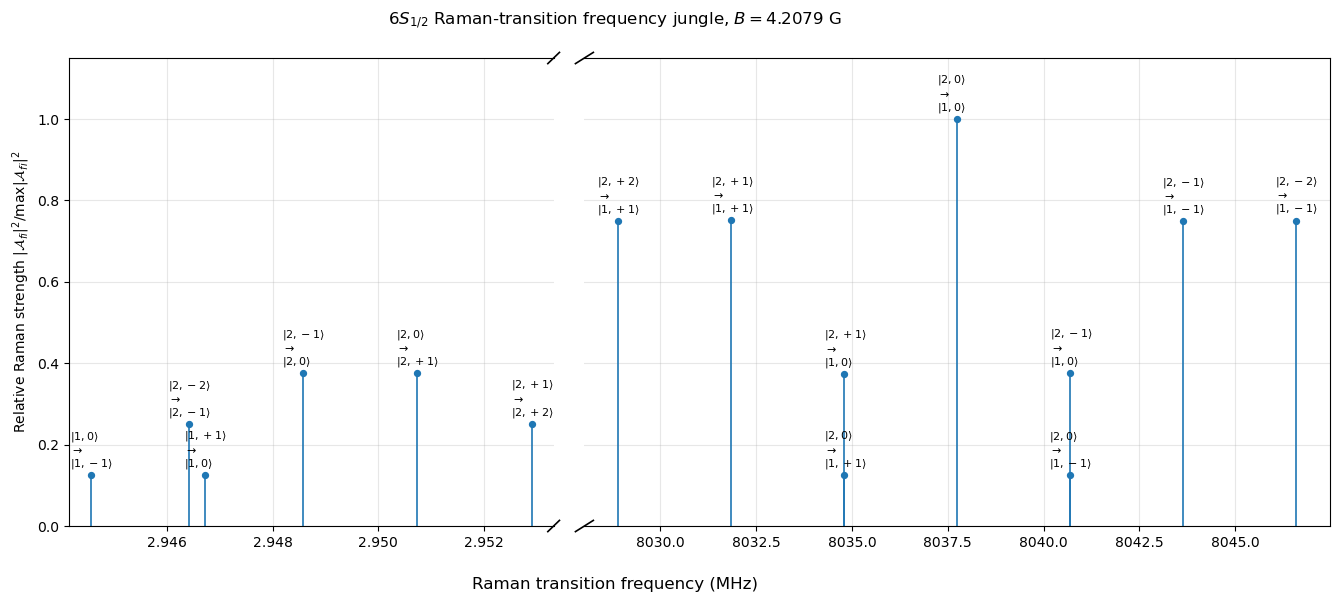

Axis break inserted between 2.953 MHz and 8028.900 MHz.


In [12]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Experimental parameters
# ------------------------------------------------------------
B_gauss = 4.2079
wavelength_nm = 532.0


k = 45
phi = 0
chi = -45

beam1_polarization = elliptical_polarization_from_geometry(
    beam_angle_deg=k,
    polarization_angle_deg=phi,
    ellipticity_angle_deg=chi,
)
print(beam1_polarization)
beam2_polarization = elliptical_polarization_from_geometry(
    beam_angle_deg=k,
    polarization_angle_deg=phi,
    ellipticity_angle_deg=chi,
)


# ------------------------------------------------------------
# Calculate Raman strengths and S1/2 energies
# ------------------------------------------------------------
raman = RamanTransitionStrength_S12(
    B_gauss=B_gauss,
    pol1=beam1_polarization,
    pol2=beam2_polarization,
    wavelength_nm=wavelength_nm,
)

strength_matrix = np.asarray(
    raman["strength"],
    dtype=float,
).copy()

ground_energies_hz = np.asarray(
    raman["ground_energies_hz"],
    dtype=float,
)
print(ground_energies_hz)
# Exclude state-preserving transitions.
np.fill_diagonal(strength_matrix, 0.0)

strength_matrix = strength_matrix / np.max(strength_matrix)

# ------------------------------------------------------------
# Construct the frequency-jungle data
# ------------------------------------------------------------
frequencies_hz = []
strengths = []
initial_states = []
final_states = []

number_of_states = len(ground_energies_hz)

for initial_state in range(number_of_states):
    for final_state in range(number_of_states):

        if final_state == initial_state:
            continue

        if final_state >= initial_state:
            continue

        frequency_hz = abs(
            ground_energies_hz[final_state]
            - ground_energies_hz[initial_state]
        )

        strength = strength_matrix[
            final_state,
            initial_state
        ]
        if strength < 1e-5:
            continue
        frequencies_hz.append(frequency_hz)
        strengths.append(strength)
        initial_states.append(initial_state)
        final_states.append(final_state)

frequencies_hz = np.asarray(frequencies_hz)
strengths = np.asarray(strengths)
initial_states = np.asarray(initial_states)
final_states = np.asarray(final_states)

# Sort transitions by frequency.
order = np.argsort(frequencies_hz)
print("Sorted frequencies (Hz):", frequencies_hz[order])
frequencies_hz = frequencies_hz[order]
strengths = strengths[order]
initial_states = initial_states[order]
final_states = final_states[order]


# ------------------------------------------------------------
# Optional removal of tiny numerical values
# ------------------------------------------------------------
relative_cutoff = 1e-5

if strengths.size > 0 and np.max(strengths) > 0:
    keep = strengths > relative_cutoff * np.max(strengths)

    frequencies_hz = frequencies_hz[keep]
    strengths = strengths[keep]
    initial_states = initial_states[keep]
    final_states = final_states[keep]


# ------------------------------------------------------------
# Plot with an automatic x-axis break at the largest gap
# ------------------------------------------------------------
frequencies_mhz = frequencies_hz / 1e6

if frequencies_mhz.size == 0:
    raise ValueError("No nonzero Raman transitions remain to plot.")

# Find the largest gap between distinct transition frequencies.
unique_frequencies = np.unique(frequencies_mhz)
unique_frequencies.sort()

if unique_frequencies.size < 2:
    raise ValueError(
        "At least two distinct transition frequencies are required "
        "to create an axis break."
    )

frequency_gaps = np.diff(unique_frequencies)
gap_index = np.argmax(frequency_gaps)

left_cluster_max = unique_frequencies[gap_index]
right_cluster_min = unique_frequencies[gap_index + 1]

# Add a little space around each cluster.
left_cluster_min = unique_frequencies[0]
right_cluster_max = unique_frequencies[-1]

left_span = max(left_cluster_max - left_cluster_min, 1.0)
right_span = max(right_cluster_max - right_cluster_min, 1.0)

left_pad_left = 5.0
left_pad_right = 10.0      # increase this

right_pad_left = 5.0
right_pad_right = 10.0     # increase this

left_xlim = (
    max(0.0, left_cluster_min - left_pad_left),
    left_cluster_max + left_pad_right,
)

right_xlim = (
    right_cluster_min - right_pad_left,
    right_cluster_max + right_pad_right,
)

# Make the panel widths approximately reflect the frequency spans,
# while preventing either panel from becoming too narrow.
width_ratio = np.clip(
    (left_xlim[1] - left_xlim[0])
    / (right_xlim[1] - right_xlim[0]),
    0.65,
    1.5,
)

fig, (ax_left, ax_right) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(13, 6),
    gridspec_kw={
        "width_ratios": [width_ratio, 1.0],
        "wspace": 0.05,
    },
)

# ------------------------------------------------------------
# Plot each frequency cluster separately
# ------------------------------------------------------------
left_mask = (
    (frequencies_mhz >= left_xlim[0])
    & (frequencies_mhz <= left_xlim[1])
)

right_mask = (
    (frequencies_mhz >= right_xlim[0])
    & (frequencies_mhz <= right_xlim[1])
)


def plot_cluster(ax, mask):
    x = frequencies_mhz[mask]
    y = strengths[mask]
    i_states = initial_states[mask]
    f_states = final_states[mask]

    ax.vlines(
        x,
        0.0,
        y,
        linewidth=1.2,
    )

    ax.scatter(
        x,
        y,
        s=18,
        zorder=3,
    )

    # Label each transition as initial -> final.
    for frequency, strength, initial_state, final_state in zip(
        x,
        y,
        i_states,
        f_states,
    ):
        ax.annotate(
            rf"{S12_STATE_LABELS[initial_state]}" + "\n" +  rf"$\rightarrow$" + "\n" + rf"{S12_STATE_LABELS[final_state]}",
            xy=(frequency, strength),
            xytext=(-15, 3),
            textcoords="offset points",
            fontsize=8,
            rotation=0,
            ha="left",
            va="bottom",
            clip_on=False,
            annotation_clip=False,
        )

    ax.set_ylim(bottom=0.0)
    ax.grid(alpha=0.3)


plot_cluster(ax_left, left_mask)
plot_cluster(ax_right, right_mask)

ax_left.set_ylim(0, 1.15)
ax_right.set_ylim(0, 1.15)

# Hide the touching spines and duplicate y-axis labels.
ax_left.spines["right"].set_visible(False)
ax_right.spines["left"].set_visible(False)

ax_left.tick_params(
    axis="y",
    which="both",
    right=False,
)

ax_right.tick_params(
    axis="y",
    which="both",
    left=False,
    labelleft=False,
)

# Draw diagonal axis-break marks.
break_mark_size = 0.012

left_break_style = dict(
    transform=ax_left.transAxes,
    clip_on=False,
    # annotation_clip=False,
    linewidth=1.2,
    color="black",
)

right_break_style = dict(
    transform=ax_right.transAxes,
    clip_on=False,
    # annotation_clip=False,
    linewidth=1.2,
    color="black",
)

ax_left.plot(
    (1 - break_mark_size, 1 + break_mark_size),
    (-break_mark_size, +break_mark_size),
    **left_break_style,
)

ax_left.plot(
    (1 - break_mark_size, 1 + break_mark_size),
    (1 - break_mark_size, 1 + break_mark_size),
    **left_break_style,
)

ax_right.plot(
    (-break_mark_size, +break_mark_size),
    (-break_mark_size, +break_mark_size),
    **right_break_style,
)

ax_right.plot(
    (-break_mark_size, +break_mark_size),
    (1 - break_mark_size, 1 + break_mark_size),
    **right_break_style,
)

# Shared labels and title.
fig.supxlabel("Raman transition frequency (MHz)")

ax_left.set_ylabel(
    r"Relative Raman strength "
    r"$|\mathcal{A}_{fi}|^2/\max|\mathcal{A}_{fi}|^2$"
)

fig.suptitle(
    rf"$6S_{{1/2}}$ Raman-transition frequency jungle, "
    rf"$B={B_gauss:.4f}$ G",
    y=0.98,
)
fig.subplots_adjust(
    left=0.08,
    right=1.05,
    bottom=0.12,
    top=0.90,
)

plt.show()

print(
    "Axis break inserted between "
    f"{left_cluster_max:.3f} MHz and "
    f"{right_cluster_min:.3f} MHz."
)

# $D_{5/2}$ Calculations

In [26]:
B_gauss = 4.1935

k = 45
phi = 0
chi = -45

pol1 = elliptical_polarization_from_geometry(
    beam_angle_deg=k,
    polarization_angle_deg=phi,
    ellipticity_angle_deg=chi,
)

pol2 = elliptical_polarization_from_geometry(
    beam_angle_deg=k,
    polarization_angle_deg=phi,
    ellipticity_angle_deg=chi,
)

raman_D52 = RamanTransitionStrength_D52(
    B_gauss=B_gauss,
    pol1=pol1,
    pol2=pol2,
    wavelength_nm=532.0,
)

strength_D52 = raman_D52["strength"]
relative_strength_D52 = raman_D52["relative_strength"]

print(strength_D52.shape)
# (24, 24)

(24, 24)


In [27]:
D52_STATE_LABELS = [
    # F = 1
    r"$|F=1,m_F=+1\rangle$",
    r"$|F=1,m_F=0\rangle$",
    r"$|F=1,m_F=-1\rangle$",

    # F = 2
    r"$|F=2,m_F=+2\rangle$",
    r"$|F=2,m_F=+1\rangle$",
    r"$|F=2,m_F=0\rangle$",
    r"$|F=2,m_F=-1\rangle$",
    r"$|F=2,m_F=-2\rangle$",

    # F = 3
    r"$|F=3,m_F=+3\rangle$",
    r"$|F=3,m_F=+2\rangle$",
    r"$|F=3,m_F=+1\rangle$",
    r"$|F=3,m_F=0\rangle$",
    r"$|F=3,m_F=-1\rangle$",
    r"$|F=3,m_F=-2\rangle$",
    r"$|F=3,m_F=-3\rangle$",

    # F = 4
    r"$|F=4,m_F=+4\rangle$",
    r"$|F=4,m_F=+3\rangle$",
    r"$|F=4,m_F=+2\rangle$",
    r"$|F=4,m_F=+1\rangle$",
    r"$|F=4,m_F=0\rangle$",
    r"$|F=4,m_F=-1\rangle$",
    r"$|F=4,m_F=-2\rangle$",
    r"$|F=4,m_F=-3\rangle$",
    r"$|F=4,m_F=-4\rangle$",
]

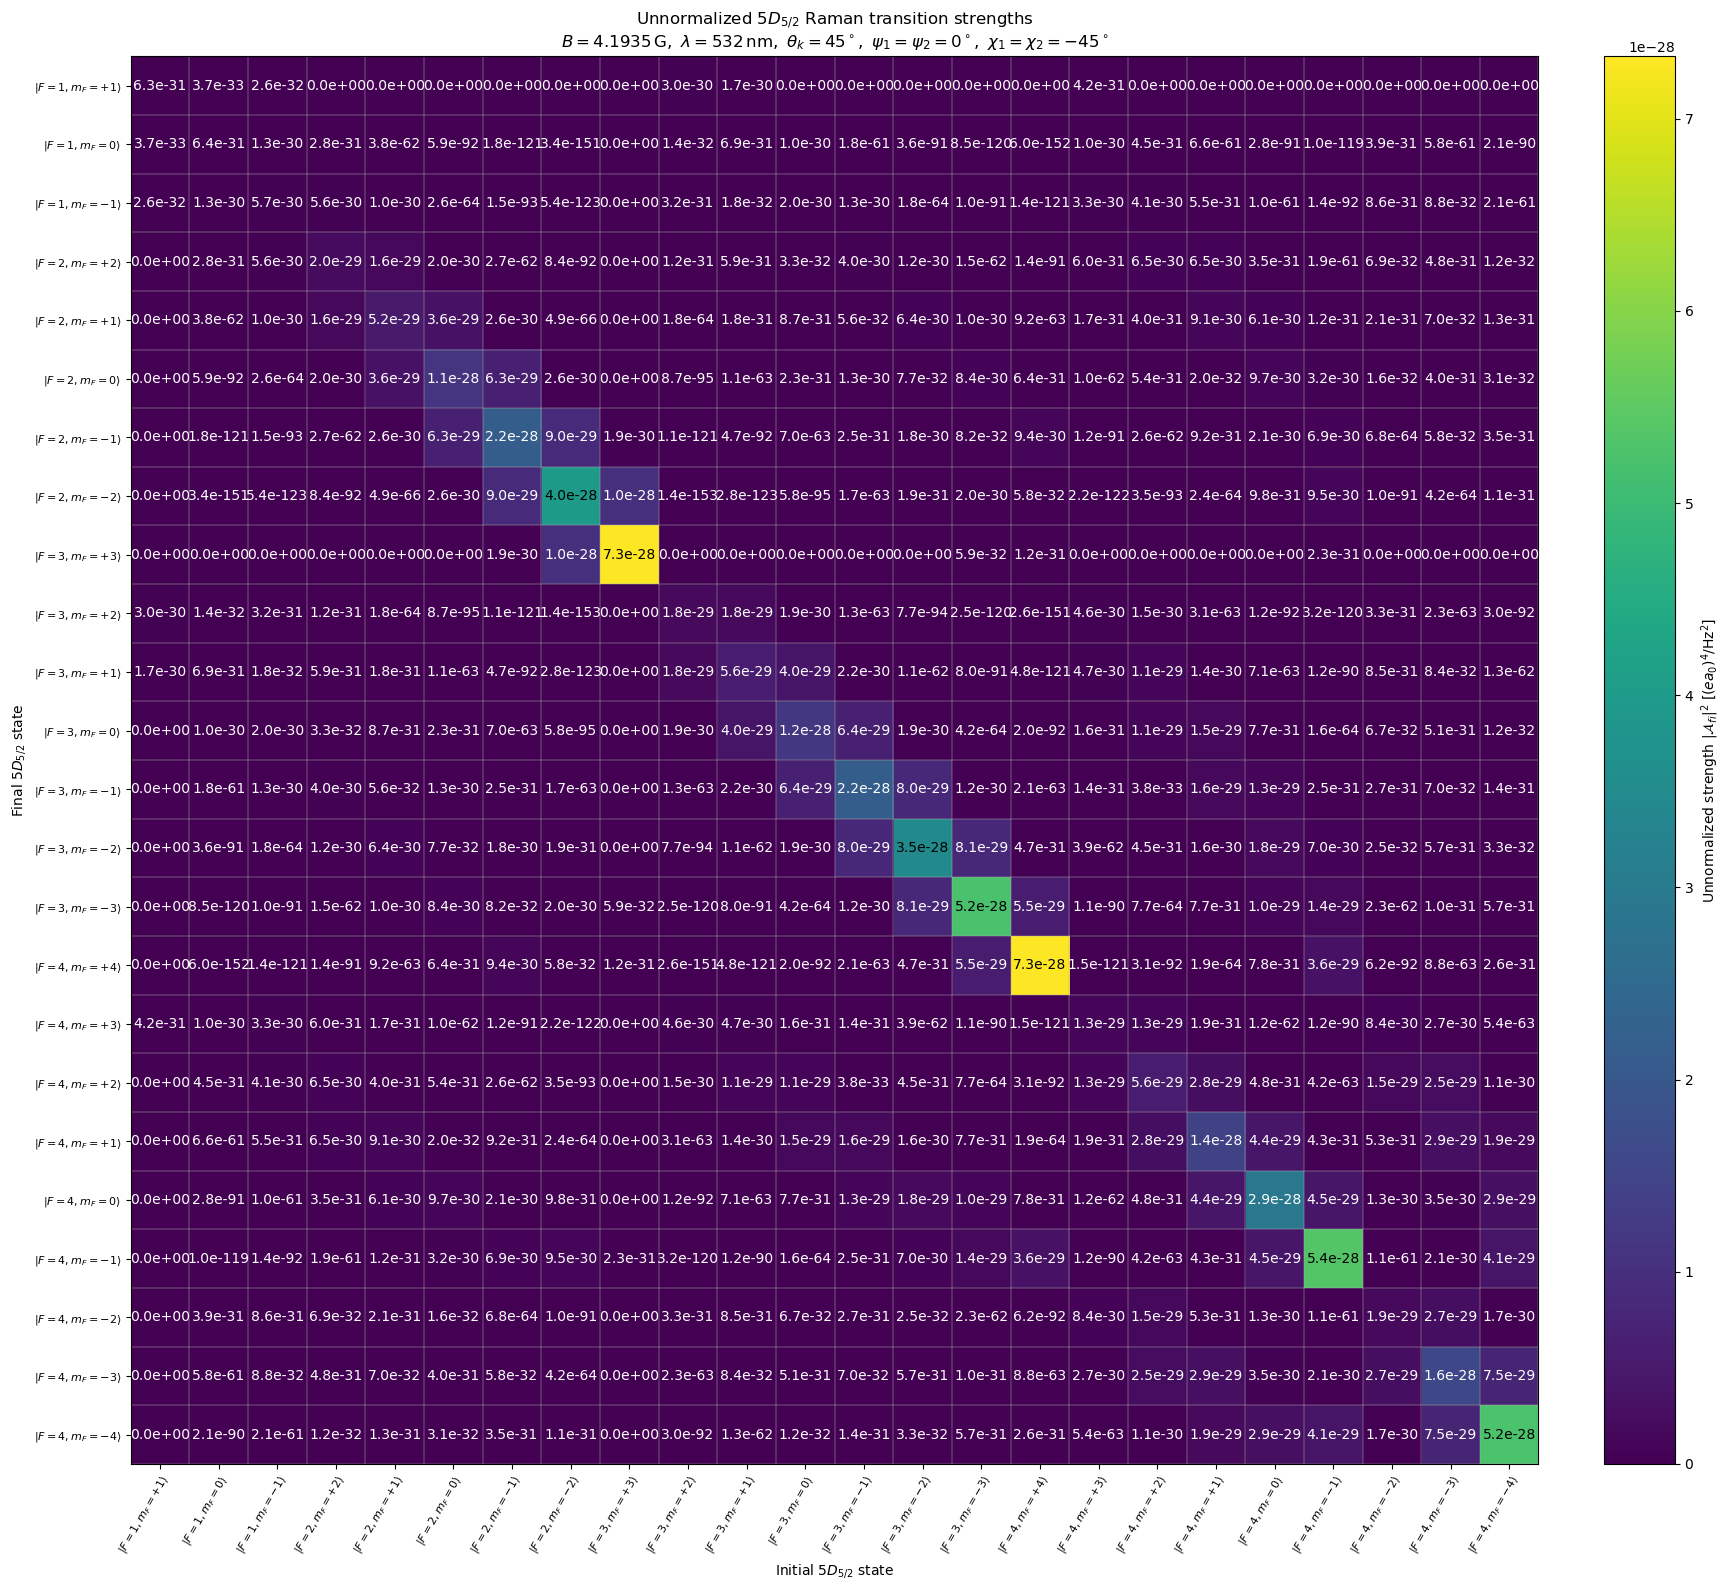

In [39]:
raman_D52 = RamanTransitionStrength_D52(
    B_gauss=B_gauss,
    pol1=pol1,
    pol2=pol2,
    wavelength_nm=532.0,
)

strength = np.asarray(
    raman_D52["strength"],
    dtype=float,
)

# Remove same-state transitions from the displayed matrix.
# np.fill_diagonal(strength, 0.0)

# strength = strength / np.max(strength) 

# Optional: remove state-preserving processes from the Raman plot.
# np.fill_diagonal(strength, 0.0)

fig, ax = plt.subplots(figsize=(18, 16))

image = ax.imshow(
    strength,
    origin="upper",
    interpolation="nearest",
    aspect="equal",
)

number_of_states = len(D52_STATE_LABELS)

ax.set_xticks(np.arange(number_of_states))
ax.set_yticks(np.arange(number_of_states))

ax.set_xticklabels(
    D52_STATE_LABELS,
    rotation=60,
    ha="right",
    rotation_mode="anchor",
    fontsize=8,
)

ax.set_yticklabels(
    D52_STATE_LABELS,
    fontsize=8,
)

ax.set_xlabel("Initial $5D_{5/2}$ state")
ax.set_ylabel("Final $5D_{5/2}$ state")

ax.set_title(
    "Unnormalized $5D_{5/2}$ Raman transition strengths\n"
    fr"$B={B_gauss}\,\mathrm{{G}},\ "
    fr"\lambda=532\,\mathrm{{nm}},\ "
    fr"\theta_k={k}^\circ,\ "
    fr"\psi_1=\psi_2={phi}^\circ,\ "
    fr"\chi_1=\chi_2={chi}^\circ$"
)

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

colorbar.set_label(
    r"Unnormalized strength "
    r"$|\mathcal{A}_{fi}|^2$ "
    r"$[(ea_0)^4/\mathrm{Hz}^2]$"
)

# Draw boundaries around matrix cells.
ax.set_xticks(
    np.arange(-0.5, number_of_states, 1),
    minor=True,
)

ax.set_yticks(
    np.arange(-0.5, number_of_states, 1),
    minor=True,
)

ax.grid(
    which="minor",
    linewidth=0.35,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

maximum = np.max(strength)

# Annotation threshold relative to the strongest transition.
annotation_cutoff = 1e-6

for final_state in range(strength.shape[0]):
    for initial_state in range(strength.shape[1]):

        value = strength[final_state, initial_state]

        # if value <= annotation_cutoff:
        #     continue

        relative_to_maximum = (
            value / maximum
            if maximum > 0
            else 0.0
        )

        text_color = (
            "black"
            if relative_to_maximum > 0.45
            else "white"
        )

        ax.text(
            initial_state,
            final_state,
            f"{value:.1e}",
            ha="center",
            va="center",
            fontsize=10,
            color=text_color,
            rotation=0,
        )

fig.tight_layout()
plt.show()

# $S_{1/2}$ Optimizer

In [66]:
S12_STATE_LABELS = [
    "|1,-1>",   # 0
    "|1, 0>",   # 1
    "|1,+1>",   # 2
    "|2,+2>",   # 3
    "|2,+1>",   # 4
    "|2, 0>",   # 5
    "|2,-1>",   # 6
    "|2,-2>",   # 7
]
CLOCK_INITIAL = 5
CLOCK_FINAL = 1

In [67]:
import numpy as np
from scipy.optimize import differential_evolution


B_gauss = 4.2079
wavelength_nm = 532.0

CLOCK_INITIAL = 5   # |F=2, mF=0>
CLOCK_FINAL = 1     # |F=1, mF=0>


def evaluate_raman_metrics(
    beam1_angles,
    beam2_angles,
    regularization=1e-12,
):
    """
    Evaluate clock-transition and overall Raman/Stark metrics.

    Parameters
    ----------
    beam1_angles, beam2_angles : array-like
        [theta_k, psi, chi] in degrees.

    regularization : float
        Small dimensionless regularization applied to Stark-shift
        denominators. This prevents the optimizer from exploiting
        numerical roundoff at an exact Stark cancellation.

    Returns
    -------
    dict
        Contains the clock and overall coupling metrics.
    """

    theta1, psi1, chi1 = beam1_angles
    theta2, psi2, chi2 = beam2_angles

    pol1 = elliptical_polarization_from_geometry(
        beam_angle_deg=theta1,
        polarization_angle_deg=psi1,
        ellipticity_angle_deg=chi1,
    )

    pol2 = elliptical_polarization_from_geometry(
        beam_angle_deg=theta2,
        polarization_angle_deg=psi2,
        ellipticity_angle_deg=chi2,
    )

    # Cross-beam Raman amplitude:
    #
    # beam 1 is absorbed and beam 2 stimulates emission.
    cross_result = RamanTransitionStrength_S12(
        B_gauss=B_gauss,
        pol1=pol1,
        pol2=pol2,
        wavelength_nm=wavelength_nm,
    )

    cross_amplitude = np.asarray(
        cross_result["amplitude"],
        dtype=complex,
    )

    # Beam-1 diagonal second-order contribution.
    beam1_result = RamanTransitionStrength_S12(
        B_gauss=B_gauss,
        pol1=pol1,
        pol2=pol1,
        wavelength_nm=wavelength_nm,
    )

    # Beam-2 diagonal second-order contribution.
    beam2_result = RamanTransitionStrength_S12(
        B_gauss=B_gauss,
        pol1=pol2,
        pol2=pol2,
        wavelength_nm=wavelength_nm,
    )

    beam1_self_amplitude = np.asarray(
        beam1_result["amplitude"],
        dtype=complex,
    )

    beam2_self_amplitude = np.asarray(
        beam2_result["amplitude"],
        dtype=complex,
    )

    # Equal beam intensities are assumed.
    #
    # The diagonal self-amplitudes should be real apart from small
    # numerical errors, so take the real part explicitly.
    total_stark_coefficient = np.real(
        np.diag(beam1_self_amplitude)
        + np.diag(beam2_self_amplitude)
    )

    # ----------------------------------------------------------
    # Metric 1: clock-transition Raman/Stark ratio
    # ----------------------------------------------------------

    clock_amplitude = cross_amplitude[
        CLOCK_FINAL,
        CLOCK_INITIAL,
    ]

    clock_rabi_coefficient = np.abs(clock_amplitude)

    clock_differential_stark = (
        total_stark_coefficient[CLOCK_FINAL]
        - total_stark_coefficient[CLOCK_INITIAL]
    )

    # Scale used only for regularization.
    stark_scale = max(
        np.max(np.abs(total_stark_coefficient)),
        np.finfo(float).tiny,
    )

    clock_stark_denominator = (
        np.abs(clock_differential_stark)
        + regularization * stark_scale
    )

    clock_ratio = (
        clock_rabi_coefficient
        / clock_stark_denominator
    )

    # ----------------------------------------------------------
    # Metric 2: overall Raman/Stark ratio
    #
    # Numerator:
    #     RMS of all off-diagonal Raman amplitudes.
    #
    # Denominator:
    #     RMS variation of the state light shifts about their mean.
    # ----------------------------------------------------------

    off_diagonal_mask = ~np.eye(
        cross_amplitude.shape[0],
        dtype=bool,
    )

    off_diagonal_amplitudes = cross_amplitude[
        off_diagonal_mask
    ]

    overall_rabi_rms = np.sqrt(
        np.mean(np.abs(off_diagonal_amplitudes) ** 2)
    )

    mean_stark = np.mean(total_stark_coefficient)

    overall_stark_rms = np.sqrt(
        np.mean(
            (
                total_stark_coefficient
                - mean_stark
            ) ** 2
        )
    )

    overall_stark_denominator = (
        overall_stark_rms
        + regularization * stark_scale
    )

    overall_ratio = (
        overall_rabi_rms
        / overall_stark_denominator
    )

    return {
        "clock_ratio": float(clock_ratio),
        "clock_rabi_coefficient": float(
            clock_rabi_coefficient
        ),
        "clock_differential_stark": float(
            clock_differential_stark
        ),
        "clock_amplitude": clock_amplitude,
        "overall_ratio": float(overall_ratio),
        "overall_rabi_rms": float(overall_rabi_rms),
        "overall_stark_rms": float(overall_stark_rms),
        "total_stark_coefficient": (
            total_stark_coefficient
        ),
        "cross_amplitude": cross_amplitude,
        "cross_strength": (
            np.abs(cross_amplitude) ** 2
        ),
        "pol1": pol1,
        "pol2": pol2,
        "beam1_angles": np.asarray(
            beam1_angles,
            dtype=float,
        ),
        "beam2_angles": np.asarray(
            beam2_angles,
            dtype=float,
        ),
    }

In [69]:
def decode_constrained_geometry(parameters):
    """
    Case 1:

        theta_1 = theta_2 = 45 degrees
        psi_1   = psi_2
        chi_1   = chi_2

    Free parameters:
        psi, chi
    """

    psi, chi = parameters

    beam_angles = np.array(
        [45.0, psi, chi],
        dtype=float,
    )

    return beam_angles, beam_angles.copy()

def decode_free_geometry(parameters):
    """
    Case 2: six independent variables.

        theta_1, psi_1, chi_1,
        theta_2, psi_2, chi_2
    """

    theta1, psi1, chi1, theta2, psi2, chi2 = parameters

    beam1_angles = np.array(
        [theta1, psi1, chi1],
        dtype=float,
    )

    beam2_angles = np.array(
        [theta2, psi2, chi2],
        dtype=float,
    )

    return beam1_angles, beam2_angles

def make_optimizer_objective(
    geometry_decoder,
    metric_name,
    regularization=1e-12,
):
    """
    Construct a scipy optimizer objective.

    metric_name must be either:
        "clock_ratio"
        "overall_ratio"
    """

    if metric_name not in {
        "clock_ratio",
        "overall_ratio",
    }:
        raise ValueError(
            "metric_name must be 'clock_ratio' "
            "or 'overall_ratio'."
        )

    def objective(parameters):
        try:
            beam1_angles, beam2_angles = (
                geometry_decoder(parameters)
            )

            metrics = evaluate_raman_metrics(
                beam1_angles=beam1_angles,
                beam2_angles=beam2_angles,
                regularization=regularization,
            )

            ratio = metrics[metric_name]

            if not np.isfinite(ratio) or ratio <= 0:
                return 1e100

            return -np.log10(ratio)

        except (
            ValueError,
            FloatingPointError,
            np.linalg.LinAlgError,
        ):
            return 1e100

    return objective

In [70]:
# psi is periodic over 180 degrees for the polarization ellipse.
# chi lies between -45 and +45 degrees.

constrained_bounds = [
    (0.0, 180.0),    # psi
    (-45.0, 45.0),   # chi
]

free_bounds = [
    (0.0, 180.0),    # theta_1
    (0.0, 180.0),    # psi_1
    (-45.0, 45.0),   # chi_1

    (0.0, 180.0),    # theta_2
    (0.0, 180.0),    # psi_2
    (-45.0, 45.0),   # chi_2
]

In [71]:
def run_raman_optimization(
    geometry_name,
    geometry_decoder,
    bounds,
    metric_name,
    seed=12345,
    maxiter=150,
    popsize=15,
    workers=1,
):
    objective = make_optimizer_objective(
        geometry_decoder=geometry_decoder,
        metric_name=metric_name,
    )

    result = differential_evolution(
        objective,
        bounds=bounds,
        strategy="best1bin",
        maxiter=maxiter,
        popsize=popsize,
        tol=1e-8,
        atol=0.0,
        mutation=(0.5, 1.0),
        recombination=0.7,
        seed=seed,
        polish=True,
        updating=(
            "immediate"
            if workers == 1
            else "deferred"
        ),
        workers=workers,
        disp=True,
    )

    beam1_angles, beam2_angles = geometry_decoder(
        result.x
    )

    metrics = evaluate_raman_metrics(
        beam1_angles=beam1_angles,
        beam2_angles=beam2_angles,
    )

    return {
        "geometry_name": geometry_name,
        "metric_name": metric_name,
        "optimizer_result": result,
        "beam1_angles": beam1_angles,
        "beam2_angles": beam2_angles,
        "metrics": metrics,
    }

In [72]:
optimization_results = {}

# Case 1: same direction and same polarization, theta = 45 degrees.

optimization_results[
    "constrained_clock"
] = run_raman_optimization(
    geometry_name=(
        "Co-propagating, identical polarization, "
        "theta=45 degrees"
    ),
    geometry_decoder=decode_constrained_geometry,
    bounds=constrained_bounds,
    metric_name="clock_ratio",
    seed=1,
)

optimization_results[
    "constrained_overall"
] = run_raman_optimization(
    geometry_name=(
        "Co-propagating, identical polarization, "
        "theta=45 degrees"
    ),
    geometry_decoder=decode_constrained_geometry,
    bounds=constrained_bounds,
    metric_name="overall_ratio",
    seed=2,
)

# Case 2: six independent beam parameters.

optimization_results[
    "free_clock"
] = run_raman_optimization(
    geometry_name="Six independent beam parameters",
    geometry_decoder=decode_free_geometry,
    bounds=free_bounds,
    metric_name="clock_ratio",
    seed=3,
)

optimization_results[
    "free_overall"
] = run_raman_optimization(
    geometry_name="Six independent beam parameters",
    geometry_decoder=decode_free_geometry,
    bounds=free_bounds,
    metric_name="overall_ratio",
    seed=4,
)

differential_evolution step 1: f(x)= -3.7225089940319593
differential_evolution step 2: f(x)= -3.7225089940319593
differential_evolution step 3: f(x)= -3.7225089940319593
differential_evolution step 4: f(x)= -3.7225089940319593
differential_evolution step 5: f(x)= -3.7225089940319593
differential_evolution step 6: f(x)= -3.7225089940319593
differential_evolution step 7: f(x)= -3.7225089940319593
differential_evolution step 8: f(x)= -4.132096898041587
differential_evolution step 9: f(x)= -4.847144239383653
differential_evolution step 10: f(x)= -4.927356959774482
differential_evolution step 11: f(x)= -4.978900565146651
differential_evolution step 12: f(x)= -5.890935332042331
differential_evolution step 13: f(x)= -6.204422060052169
differential_evolution step 14: f(x)= -6.204422060052169
differential_evolution step 15: f(x)= -6.204422060052169
differential_evolution step 16: f(x)= -6.459456283388549
differential_evolution step 17: f(x)= -6.459456283388549
differential_evolution step 18: f

In [73]:
import numpy as np
import matplotlib.pyplot as plt


def plot_optimized_raman_strength(
    result,
    result_name="",
    state_labels=S12_STATE_LABELS,
    annotate=True,
    annotation_cutoff=0.0,
    figsize=(11, 9),
):
    """
    Plot the raw Raman strength matrix from one optimization result.

    No normalization is applied.
    Diagonal elements are retained.
    """

    metrics = result["metrics"]

    # Raw unnormalized Raman strengths:
    # strength[f, i] = |A_fi|^2
    strength = np.asarray(
        metrics["cross_strength"],
        dtype=float,
    )

    beam1 = np.asarray(
        result["beam1_angles"],
        dtype=float,
    )

    beam2 = np.asarray(
        result["beam2_angles"],
        dtype=float,
    )

    theta1, psi1, chi1 = beam1
    theta2, psi2, chi2 = beam2

    number_of_states = strength.shape[0]

    if strength.shape != (
        number_of_states,
        number_of_states,
    ):
        raise ValueError(
            "The Raman strength matrix must be square."
        )

    if len(state_labels) != number_of_states:
        raise ValueError(
            f"Received {len(state_labels)} labels for a "
            f"{number_of_states}x{number_of_states} matrix."
        )

    fig, ax = plt.subplots(figsize=figsize)

    image = ax.imshow(
        strength,
        origin="upper",
        interpolation="nearest",
        aspect="equal",
    )

    ax.set_xticks(np.arange(number_of_states))
    ax.set_yticks(np.arange(number_of_states))

    ax.set_xticklabels(
        state_labels,
        rotation=45,
        ha="right",
        rotation_mode="anchor",
    )

    ax.set_yticklabels(state_labels)

    ax.set_xlabel("Initial $6S_{1/2}$ state")
    ax.set_ylabel("Final $6S_{1/2}$ state")

    title = (
        f"{result_name}\n"
        "Unnormalized Raman transition strengths\n"
        fr"Beam 1: $\theta_1={theta1:.3f}^\circ$, "
        fr"$\psi_1={psi1:.3f}^\circ$, "
        fr"$\chi_1={chi1:.3f}^\circ$"
        "\n"
        fr"Beam 2: $\theta_2={theta2:.3f}^\circ$, "
        fr"$\psi_2={psi2:.3f}^\circ$, "
        fr"$\chi_2={chi2:.3f}^\circ$"
    )

    ax.set_title(title)

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    colorbar.set_label(
        r"Unnormalized strength "
        r"$|\mathcal{A}_{fi}|^2$ "
        r"$[(ea_0)^4/\mathrm{Hz}^2]$"
    )

    # Draw cell boundaries.
    ax.set_xticks(
        np.arange(-0.5, number_of_states, 1.0),
        minor=True,
    )

    ax.set_yticks(
        np.arange(-0.5, number_of_states, 1.0),
        minor=True,
    )

    ax.grid(
        which="minor",
        linewidth=0.5,
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

    if annotate:
        maximum = np.max(strength)

        for final_state in range(number_of_states):
            for initial_state in range(number_of_states):
                value = strength[
                    final_state,
                    initial_state,
                ]

                if value <= annotation_cutoff:
                    continue

                relative_to_maximum = (
                    value / maximum
                    if maximum > 0
                    else 0.0
                )

                text_color = (
                    "black"
                    if relative_to_maximum > 0.45
                    else "white"
                )

                ax.text(
                    initial_state,
                    final_state,
                    f"{value:.3e}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color=text_color,
                )

    fig.tight_layout()

    return fig, ax

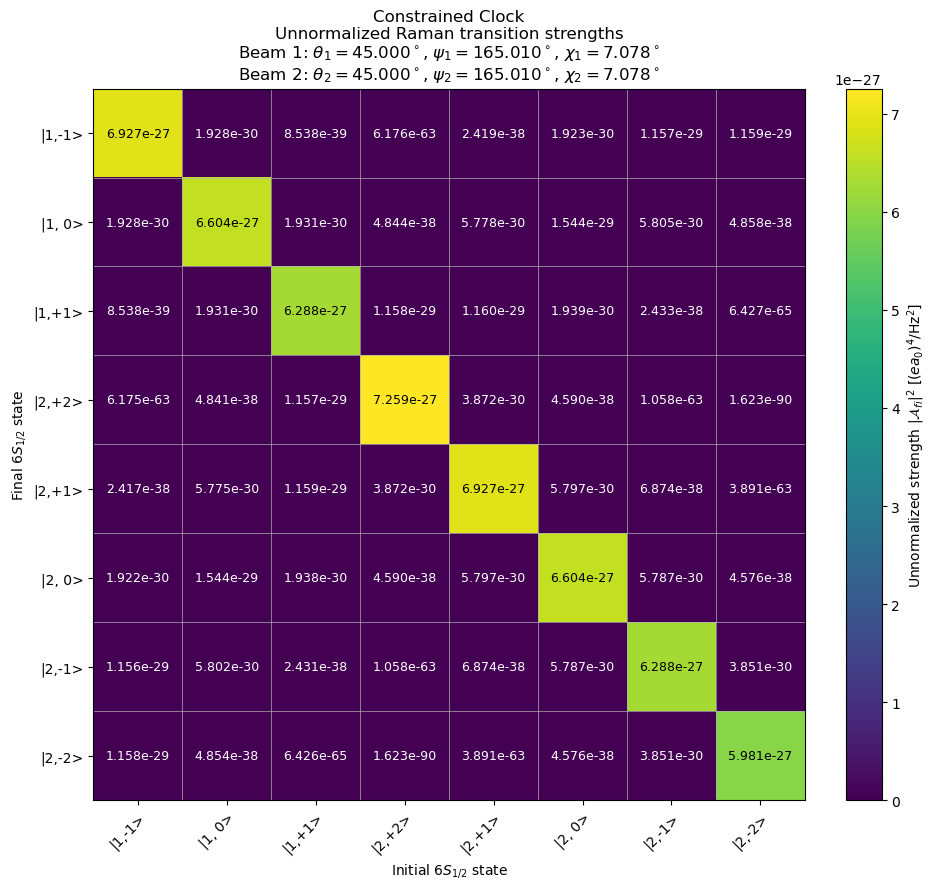

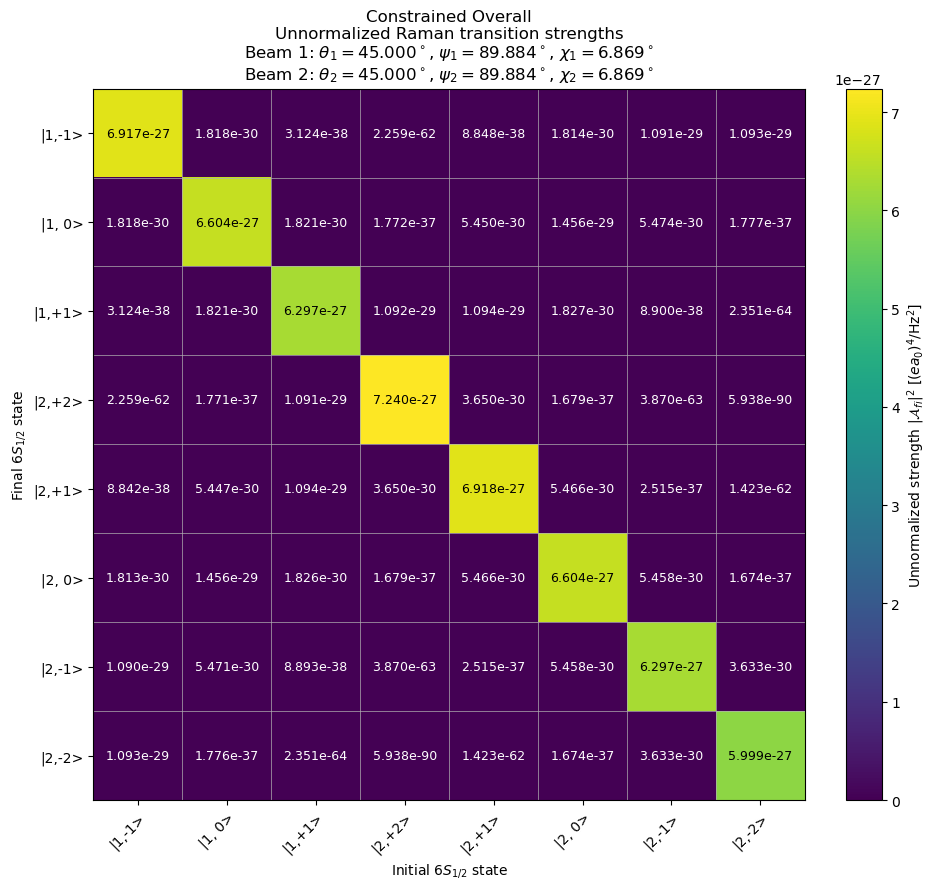

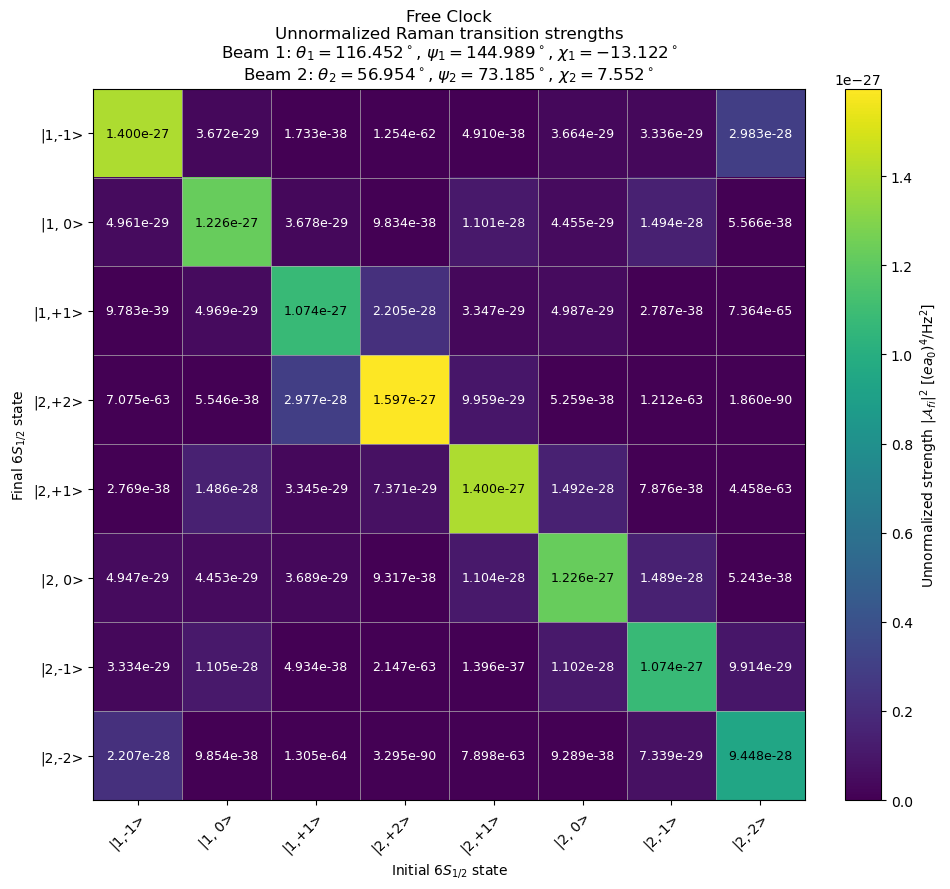

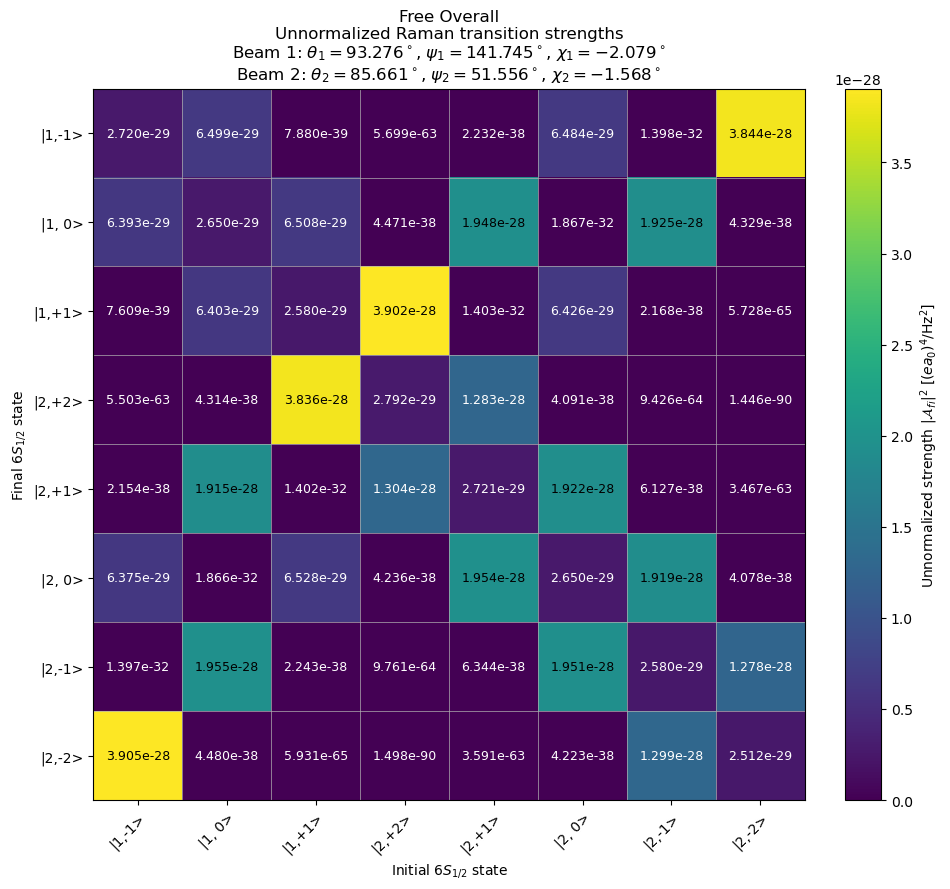

In [74]:
for name, result in optimization_results.items():
    fig, ax = plot_optimized_raman_strength(
        result=result,
        result_name=name.replace("_", " ").title(),
        state_labels=S12_STATE_LABELS,
        annotate=True,
        annotation_cutoff=0.0,
    )

    plt.show()

106

1